Thomas Sears

9-13-26

Block Checkpoint 1 - Spring-Mass System with Magnets

Simulation Description:

This notebook will simulate a 1-D system using the Euler-Cromer method containing a point mass with two Hookean springs on either side and two magnetic forces on each end.

For simplicity, I will assume the magnetic sources apply an attractive force on the point mass that is proportional to 1/r^2 where r is the distance between the mass and magnet and then multiplied by some strength coefficient, C.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Euler-Cromer Simulaion

In [2]:
# Physical Parameters (Measured in SI Units)
m = 1 # Mass
k = 1 # Spring Constant
C = 0.1 # Magnet Strength Coefficient
d = 2 # Distance From Center To Each Magnet

x0 = 1.0 # Initial Displacement (Measured to the right from the origin)
v0 = 0.0 # Initial Velocity
dt = 0.05 # Time Step
t_max = 50 # Must Use A Specific t_max Because Forces Are Non-Linear

def simulate(dt):
    # Initial conditions
    x = x0
    v = v0
    t = 0.0

    # Initialize Energy
    KE = 0.5 * m * v**2
    U_springs = k * x**2
    U_magnet_left = -C / (x + d)
    U_magnet_right = -C / (d - x)
    U = U_springs + U_magnet_left + U_magnet_right
    E = KE + U

    # Time, Position, Velocity, and Energy Arrays
    t_arr, x_arr, v_arr, E_arr = [t], [x], [v], [E]

    while t < t_max:

        # Calculate spring forces
        F_spring_left = -k * x
        F_spring_right = -k *x

        # Calculate magnetic forces
        F_magnet_left = -C / (x + d)**2
        F_magnet_right = C / (d - x)**2

        # Total force
        F = F_spring_left + F_spring_right + F_magnet_left + F_magnet_right

        # Acceleration
        a = F/m

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        t += dt

        # Update Energy
        KE = 0.5 * m * v**2
        
        U_springs = k * x**2
        
        U_magnet_left = -C / (x + d)
        U_magnet_right = -C / (d - x)
        
        U = U_springs + U_magnet_left + U_magnet_right
        
        E = KE + U

        t_arr.append(t); x_arr.append(x); v_arr.append(v); E_arr.append(E)

    return np.array(t_arr), np.array(x_arr), np.array(v_arr), np.array(E_arr)

X(t), Energy, and Phase-Space Plots

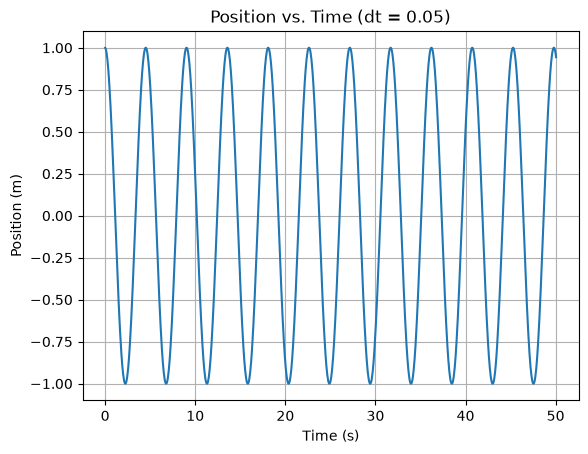

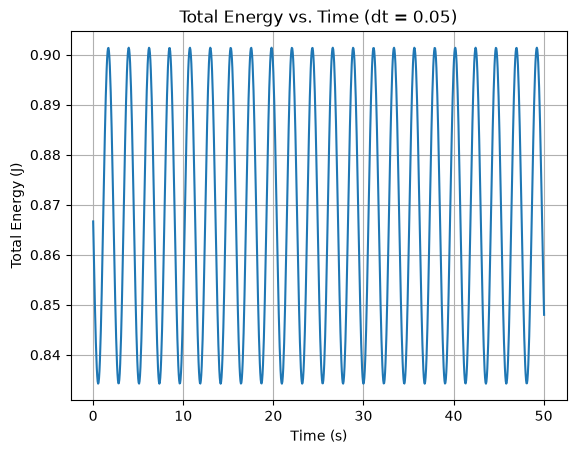

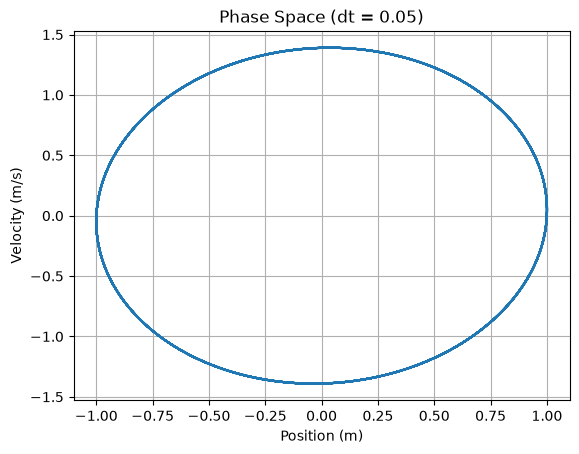

In [3]:
ts, xs, vs, Es = simulate(dt)

# Plot position vs time
plt.figure()
plt.plot(ts, xs)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs. Time (dt = 0.05)")
plt.grid()
plt.show()

# Plot energy vs time
plt.figure()
plt.plot(ts, Es)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy vs. Time (dt = 0.05)")
plt.grid()
plt.show()

# Plot phase space
plt.figure()
plt.plot(xs, vs)
plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Space (dt = 0.05)")
plt.grid()
plt.show()

Energy Convergence Test Using Decreasing dt Values

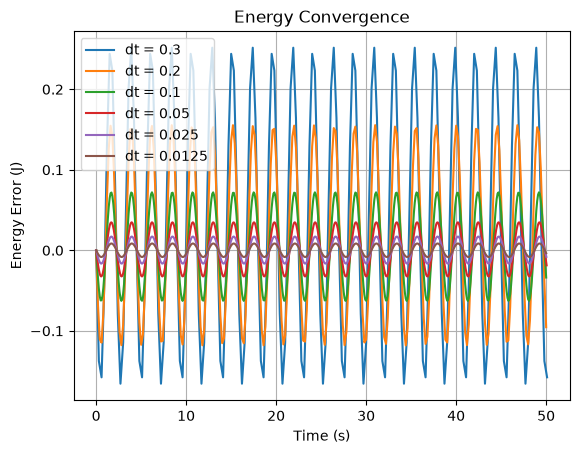

In [4]:
dt_arr = [0.3, 0.2, 0.1, 0.05, 0.025, 0.0125]

plt.figure()

for dt_test in dt_arr:
    ts, xs, vs, Es = simulate(dt_test)

    # Energy error relative to the initial energy
    energy_error = Es - Es[0]

    plt.plot(ts, energy_error, label=f"dt = {dt_test}")

plt.xlabel("Time (s)")
plt.ylabel("Energy Error (J)")
plt.title("Energy Convergence")
plt.legend()
plt.grid()
plt.show()

Discussion: 

This energy convergence plot shows how the energy drift decreases quickly as dt decreases. As dt approaches 0.01 we can see that the total energy error oscillates consistently around 0 with magnitude of error ~ 0.01 J.

Phase-Space Convergence Test Using Decreasing dt Values

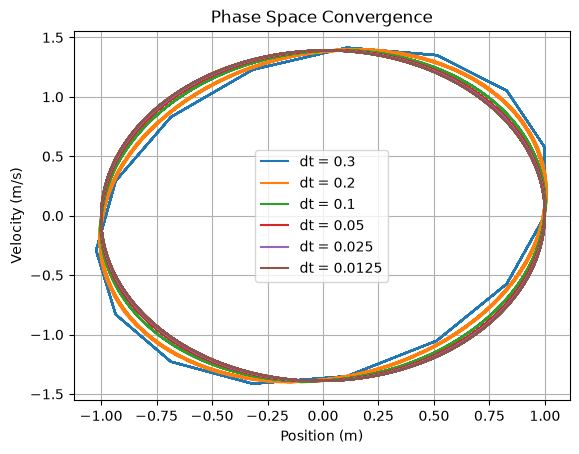

In [5]:
dt_arr = [0.3, 0.2, 0.1, 0.05, 0.025, 0.0125]

plt.figure()

for dt_convergence in dt_arr:
    ts, xs, vs, Es = simulate(dt_convergence)
    plt.plot(xs, vs, label=f"dt = {dt_convergence}")

plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Space Convergence")
plt.legend()
plt.grid()
plt.show()

Discussion:

This phase-space convergence plot shows the elliptical, oscillatory structure of the simulation as we can see phase-space plot stabilizes to the expected ellipse centered at (0,0) as dt decreases.

Does the Simulation Agree with the Physics?

The various energy, phase-space, and position plots show agreement with the basic energy conservation and SHM laws. From the x(t) plot we clearly see the mass oscillating around the origin, x = 0, and the energy plot shows that the simultion does effectively conserve energy at smaller dt values as shown in the energy convergence plot. So, I would say this simulation agrees with the physics under the proper conditions.

When Does The Simulation Fail?

One intreseting thing I found in this system is that the simulation breaks if C (the magnetic strength constant) gets too large or if the mass gets too close to the magnet. This is because the magnetic force is inversely proportional to the square of the distance and proportional to C. Meaning, the magnetic strength quickly blows up and becomes very large at high values of C or small values of distance. This makes sense physically since the simulation starts with the mass placed at the position x0 = 1.0 measured along the positive x-axis. This means the magnet on the right will be substantial stronger than the one on the left while simultaneously overpowing the spring restoring force, breaking the simulation because it operates under the assumption that the point mass does not reach the magnet. So, this is to say that the simulation is only valid for values of C that do not massively overpower the spring force and reasonable starting postion, x0, parameters.